In [17]:
from anchoring_detection.preprocess import Preprocess
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import os

In [2]:
proceso = Preprocess()

In [5]:
dataframes_surge, dataframes_sway = proceso.extract_res_files()
dataframes_surge, dataframes_sway = proceso.stabilizing_signal()

In [8]:
dataframes_surge['oc4__Hs1__Tp2__dir3__1']

,time[s],Surge
0,180.0,-1.479151
1,180.1,-1.476411
2,180.2,-1.473671
3,180.3,-1.470971
4,180.4,-1.468291
...,...,...
10196,1199.6,0.067959
10197,1199.7,0.064109
10198,1199.8,0.060319
10199,1199.9,0.056589


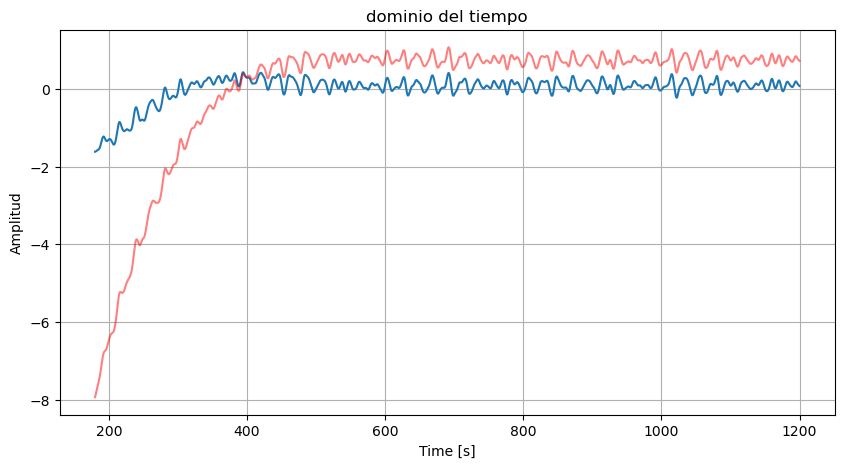

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(dataframes_surge['oc4__Hs2__Tp3__dir3__1']['time[s]'],dataframes_surge['oc4__Hs2__Tp3__dir3__1']['Surge'])
plt.plot(dataframes_surge['oc4__Hs2__Tp3__dir3__2']['time[s]'],dataframes_surge['oc4__Hs2__Tp3__dir3__2']['Surge'],color='r',alpha=0.5)
plt.title('dominio del tiempo')
plt.xlabel('Time [s]')
plt.ylabel('Amplitud')
plt.grid()

In [14]:
movements = ['Surge','Sway']

for mov in movements:
    if mov == 'Surge':
        dataframes = dataframes_surge
    else:
        dataframes = dataframes_sway

    # Group the data in one unique dataframe
    df= pd.concat(dataframes.values(), axis=1)
    df_time = df.iloc[:,0]
    df = df.drop(df.filter(like='time[s]').columns, axis=1)
    df.insert(0,'Time',df_time)

    # the number of txt files is the same of dataframe amplitude columns. We are going to regroup with only one "freq_colum" because it is the same
    path = rf'D:\arturo_sim\simulaciones\acoplado\txt'
    lista_archivos = os.listdir(path)

    if len(lista_archivos) == (len(df.columns) - 1):
        df.columns = ['Time'] + lista_archivos

    if mov == 'Surge':
        df_surge = df
    else:
        df_sway = df

C:\Users\naval\AppData\Local\Temp\ipykernel_15588\2148312684.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(0,'Time',df_time)
C:\Users\naval\AppData\Local\Temp\ipykernel_15588\2148312684.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(0,'Time',df_time)


In [15]:
df_surge

,Time,oc4__Hs1__Tp2__dir1__1.txt,oc4__Hs1__Tp2__dir1__2.txt,oc4__Hs1__Tp2__dir2__1.txt,oc4__Hs1__Tp2__dir2__2.txt,oc4__Hs1__Tp2__dir3__1.txt,oc4__Hs1__Tp2__dir3__2.txt,oc4__Hs1__Tp2__dir4__1.txt,oc4__Hs1__Tp2__dir4__2.txt,oc4__Hs1__Tp2__dir5__1.txt,...,oc4__Hs4__Tp5__dir1__1.txt,oc4__Hs4__Tp5__dir1__2.txt,oc4__Hs4__Tp5__dir2__1.txt,oc4__Hs4__Tp5__dir2__2.txt,oc4__Hs4__Tp5__dir3__1.txt,oc4__Hs4__Tp5__dir3__2.txt,oc4__Hs4__Tp5__dir4__1.txt,oc4__Hs4__Tp5__dir4__2.txt,oc4__Hs4__Tp5__dir5__1.txt,oc4__Hs4__Tp5__dir5__2.txt
0,180.0,-1.493449,-7.806978,-1.45896,-7.772465,-1.479151,-7.792413,-1.487987,-7.800819,-1.563892,...,-0.456509,-6.788895,-0.959113,-7.275642,-1.466601,-7.768536,-1.890862,-8.179824,-2.31354,-8.585323
1,180.1,-1.487229,-7.794478,-1.45465,-7.761865,-1.476411,-7.783313,-1.487917,-7.794519,-1.568332,...,-0.345659,-6.671995,-0.898053,-7.208442,-1.461601,-7.757236,-1.942172,-8.224724,-2.42752,-8.692723
2,180.2,-1.481179,-7.782078,-1.45049,-7.751365,-1.473671,-7.774313,-1.487807,-7.788019,-1.572342,...,-0.233649,-6.553895,-0.836813,-7.141042,-1.456951,-7.746336,-1.994352,-8.270524,-2.54246,-8.801023
3,180.3,-1.475329,-7.769978,-1.44652,-7.741065,-1.470971,-7.765313,-1.487647,-7.781619,-1.575892,...,-0.120609,-6.434795,-0.775443,-7.073542,-1.452661,-7.735736,-2.047332,-8.317024,-2.65822,-8.910123
4,180.4,-1.469719,-7.758078,-1.44272,-7.731065,-1.468291,-7.756313,-1.487427,-7.775119,-1.578942,...,-0.006669,-6.314795,-0.714023,-7.005942,-1.448711,-7.725536,-2.101022,-8.364324,-2.77465,-9.019893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10196,1199.6,-0.061139,0.587722,-0.00420,0.644635,0.067959,0.716687,0.143353,0.791981,0.247318,...,6.113841,6.697605,3.094427,3.710558,0.089769,0.729564,-2.892642,-2.249324,-5.81773,-5.190123
10197,1199.7,-0.056619,0.592322,-0.00595,0.642935,0.064109,0.712887,0.137233,0.785881,0.245938,...,6.181641,6.765505,3.127207,3.743358,0.090729,0.730464,-2.924672,-2.281424,-5.87973,-5.252023
10198,1199.8,-0.051839,0.597022,-0.00757,0.641335,0.060319,0.709087,0.131083,0.779781,0.244268,...,6.244471,6.828505,3.157277,3.773358,0.091349,0.730964,-2.954492,-2.311224,-5.93683,-5.309123
10199,1199.9,-0.046819,0.602122,-0.00902,0.639835,0.056589,0.705387,0.124923,0.773581,0.242278,...,6.302271,6.886405,3.184617,3.800758,0.091639,0.731164,-2.982102,-2.338924,-5.98913,-5.361323


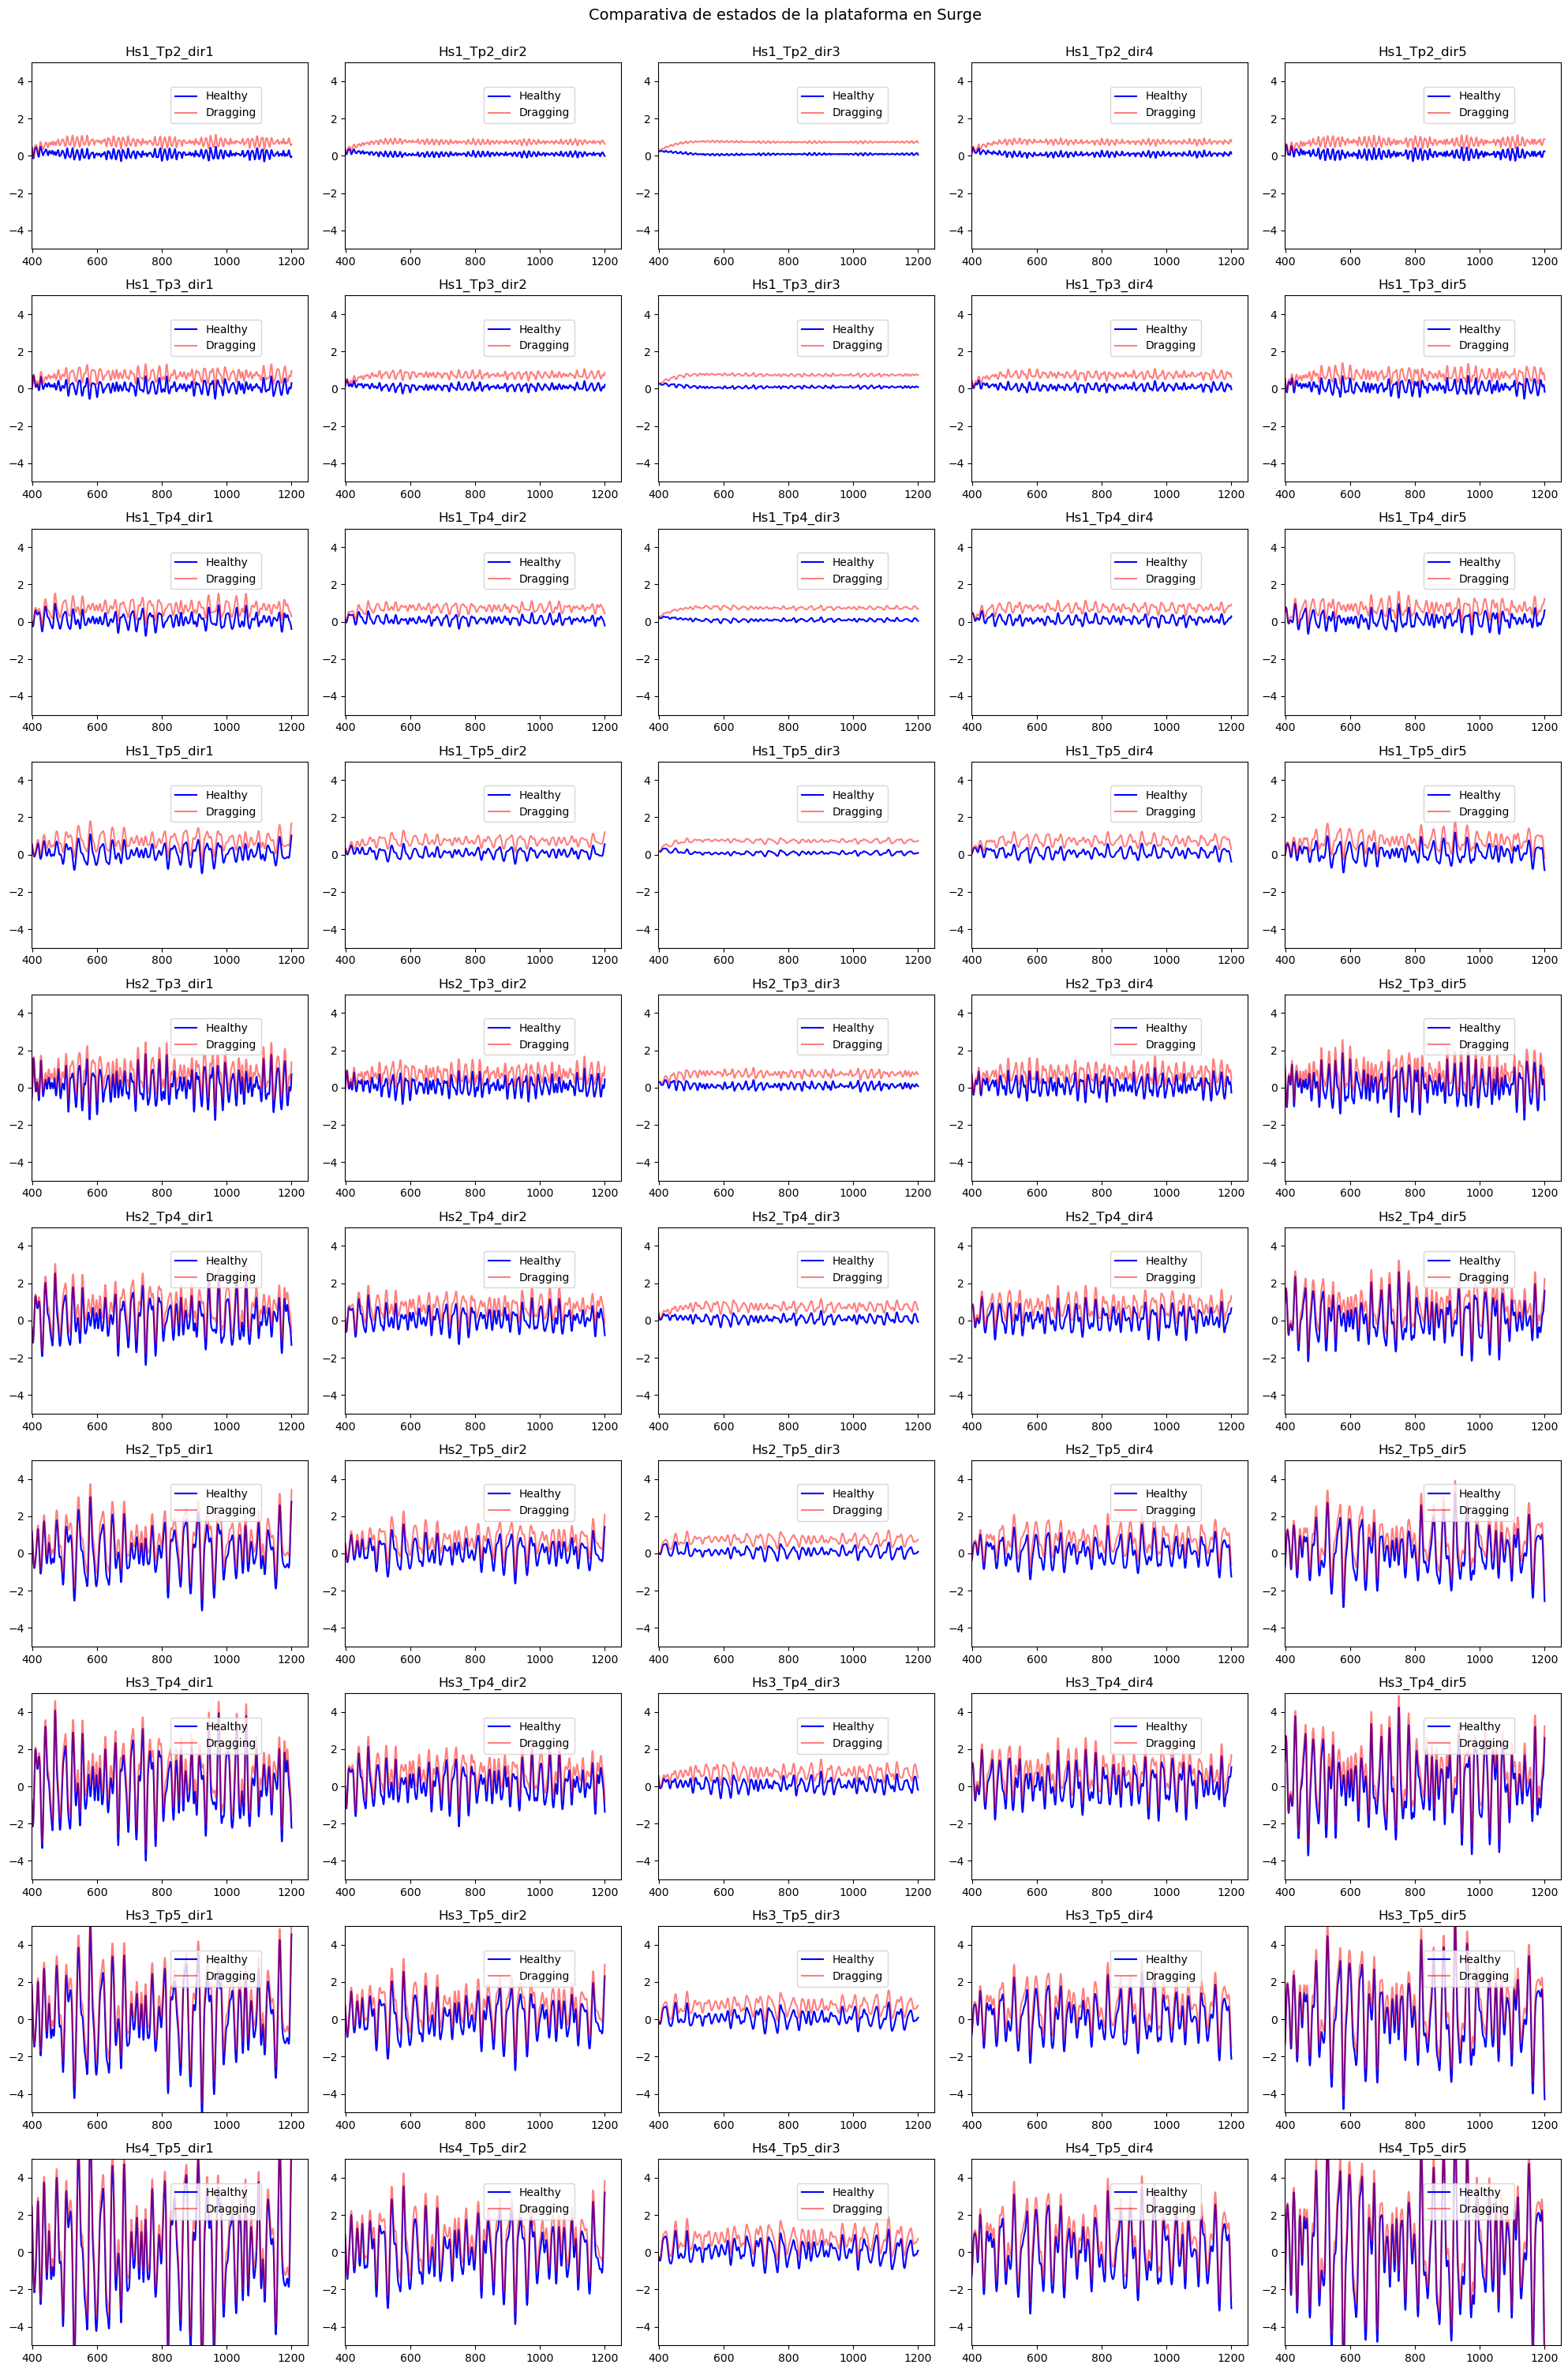

In [36]:
Hs =  ['Hs1','Hs2','Hs3','Hs4']
Tp = ['Tp2','Tp3','Tp4','Tp5']
direction = ['dir1','dir2','dir3','dir4','dir5']
mov = 'Surge'

figsize = (40,40)
hspace = 0.8
wspace = 0.2

# Crea la figura y la cuadrícula de subplots
plt.figure(figsize=figsize)
gs = gridspec.GridSpec(10, 5, width_ratios=[1, 1, 1, 1, 1])
subplot_index = 0

# Itera sobre cada celda de la cuadrícula de subplots y asigna los datos correspondientes
if mov =='Surge':
    df = df_surge
elif mov == 'Sway':
    df = df_sway

for h in Hs:
    for t in Tp:
        for dir in direction:
            filename = f'oc4__{h}__{t}__{dir}__case.txt'
            ax = plt.subplot(gs[subplot_index])
            ax.figure.set_size_inches(20,30)
            if filename.replace('case', '1') in df.columns and filename.replace('case', '2') in df.columns:
                ax.plot(df['Time'], df[filename.replace('case', '1')], color='b', label='Healthy')
                ax.plot(df['Time'], df[filename.replace('case', '2')], color='r', label='Dragging', alpha=0.5)
                ax.set_xlim(398.1,1250)
                ax.set_ylim(-5,5)
                ax.set_title(f'{h}_{t}_{dir}')
                ax.legend(['Healthy', 'Dragging'], loc='upper right', bbox_to_anchor=(0.85, 0.9))

                subplot_index +=1

# Ajusta el espacio entre los subplots
plt.subplots_adjust(top=1.4,bottom=1.2, hspace=hspace, wspace=wspace)

# Agrega un título general y una leyenda
plt.suptitle(f'Comparativa de estados de la plataforma en {mov}',y=1,fontsize=14)
plt.tight_layout()

# Muestra el gráfico
plt.show()

In [38]:
for mov in movements:
    if mov == 'Surge':
        df = df_surge
    else:
        df = df_sway

    umbral=0.001
    for index, row in df.iterrows():
        if abs(row['oc4__Hs1__Tp2__dir1__1.txt'] - row['oc4__Hs1__Tp2__dir1__2.txt']) < umbral:
            limit = row['Time']
            print(f"Tiempo de estabilización en el estado de Garreo --> {limit} | MOVIMIENTO --> {mov}")
            break

Tiempo de estabilización en el estado de Garreo --> 398.1 | MOVIMIENTO --> Surge
Tiempo de estabilización en el estado de Garreo --> 440.5 | MOVIMIENTO --> Sway


In [39]:
df_surge = df[df['Time'] >= 398.1]
df_sway = df[df['Time'] >= 440.5]

In [41]:
stats_surge = df_surge.describe()
stats_sway = df_sway.describe()